In [1]:
import os
print(os.getcwd())
print(os.listdir())

/Users/jp/Desktop/Projects/Fraud_Analysis
['creditcard.csv', '01_exploration.ipynb', '.ipynb_checkpoints']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('creditcard.csv')

# Basic overview
print(f"Total transactions: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nFraud cases: {df['Class'].sum():,}")
print(f"Legitimate cases: {(df['Class'] == 0).sum():,}")
print(f"Fraud rate: {df['Class'].mean():.4%}")
print(f"\nAny missing values? {df.isnull().sum().any()}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Total transactions: 284,807
Total columns: 31

Fraud cases: 492
Legitimate cases: 284,315
Fraud rate: 0.1727%

Any missing values? False

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [3]:
#Understand the data distributions
print("=== Transaction Amount Stats ===")
print(f"Average transaction: ${df['Amount'].mean():.2f}")
print(f"Largest transaction: ${df['Amount'].max():.2f}")
print(f"Smallest transaction: ${df['Amount'].min():.2f}")

print("\n=== Fraud vs Legitimate — Amount Comparison ===")
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print(f"Average FRAUD amount:      ${fraud['Amount'].mean():.2f}")
print(f"Average LEGITIMATE amount: ${legit['Amount'].mean():.2f}")
print(f"Max FRAUD amount:          ${fraud['Amount'].max():.2f}")
print(f"Max LEGITIMATE amount:     ${legit['Amount'].max():.2f}")

print("\n=== Time Distribution ===")
print(f"Dataset spans: {df['Time'].max()/3600:.1f} hours of transactions")
print(f"Fraud cases in first half:  {len(fraud[fraud['Time'] <= df['Time'].median()])}")
print(f"Fraud cases in second half: {len(fraud[fraud['Time'] > df['Time'].median()])}")

=== Transaction Amount Stats ===
Average transaction: $88.35
Largest transaction: $25691.16
Smallest transaction: $0.00

=== Fraud vs Legitimate — Amount Comparison ===
Average FRAUD amount:      $122.21
Average LEGITIMATE amount: $88.29
Max FRAUD amount:          $2125.87
Max LEGITIMATE amount:     $25691.16

=== Time Distribution ===
Dataset spans: 48.0 hours of transactions
Fraud cases in first half:  269
Fraud cases in second half: 223


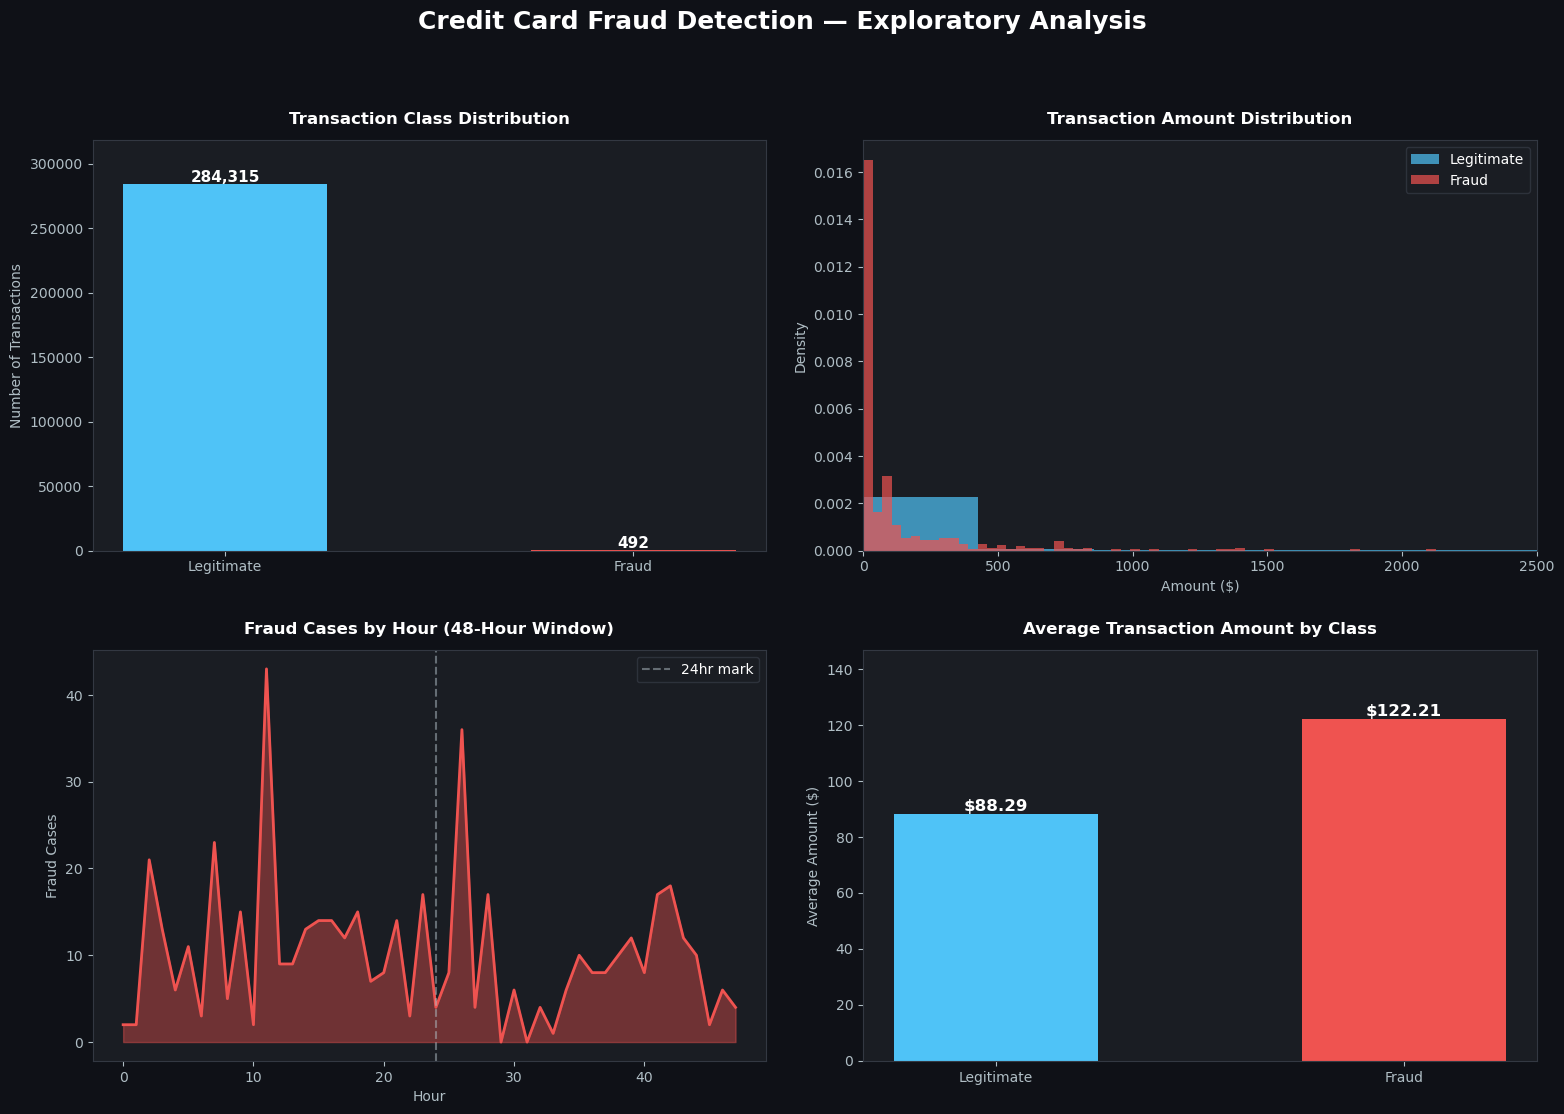

✓ Charts saved to eda_charts.png


In [5]:
# Visualizations
plt.style.use('dark_background')

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor('#0F1117')
fig.suptitle('Credit Card Fraud Detection — Exploratory Analysis', 
             fontsize=18, fontweight='bold', color='white', y=1.02)

BLUE = '#4FC3F7'
RED = '#EF5350'
GRAY = '#B0BEC5'
BG = '#1A1D23'

for ax in axes.flat:
    ax.set_facecolor(BG)
    ax.tick_params(colors=GRAY)
    ax.xaxis.label.set_color(GRAY)
    ax.yaxis.label.set_color(GRAY)
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333842')

# Chart 1 — Class imbalance
bars = axes[0, 0].bar(['Legitimate', 'Fraud'], 
                       [legit.shape[0], fraud.shape[0]], 
                       color=[BLUE, RED], width=0.5, edgecolor='none')
axes[0, 0].set_title('Transaction Class Distribution', fontweight='bold', pad=12)
axes[0, 0].set_ylabel('Number of Transactions')
for bar, v in zip(bars, [legit.shape[0], fraud.shape[0]]):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 2000, 
                    f'{v:,}', ha='center', color='white', fontweight='bold', fontsize=11)
axes[0, 0].set_ylim(0, legit.shape[0] * 1.12)

# Chart 2 — Amount distribution
axes[0, 1].hist(legit['Amount'], bins=60, alpha=0.7, 
                color=BLUE, label='Legitimate', density=True)
axes[0, 1].hist(fraud['Amount'], bins=60, alpha=0.7, 
                color=RED, label='Fraud', density=True)
axes[0, 1].set_title('Transaction Amount Distribution', fontweight='bold', pad=12)
axes[0, 1].set_xlabel('Amount ($)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend(facecolor='#1A1D23', edgecolor='#333842', labelcolor='white')
axes[0, 1].set_xlim(0, 2500)

# Chart 3 — Fraud by hour
df['Hour'] = (df['Time'] / 3600).astype(int)
fraud_by_hour = df[df['Class']==1].groupby('Hour').size().reindex(range(48), fill_value=0)
axes[1, 0].fill_between(fraud_by_hour.index, fraud_by_hour.values, 
                         alpha=0.4, color=RED)
axes[1, 0].plot(fraud_by_hour.index, fraud_by_hour.values, 
                color=RED, linewidth=2)
axes[1, 0].set_title('Fraud Cases by Hour (48-Hour Window)', fontweight='bold', pad=12)
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Fraud Cases')
axes[1, 0].axvline(x=24, color=GRAY, linestyle='--', alpha=0.5, label='24hr mark')
axes[1, 0].legend(facecolor='#1A1D23', edgecolor='#333842', labelcolor='white')

# Chart 4 — Average amount comparison
categories = ['Legitimate', 'Fraud']
amounts = [legit['Amount'].mean(), fraud['Amount'].mean()]
bars2 = axes[1, 1].bar(categories, amounts, color=[BLUE, RED], 
                        width=0.5, edgecolor='none')
axes[1, 1].set_title('Average Transaction Amount by Class', fontweight='bold', pad=12)
axes[1, 1].set_ylabel('Average Amount ($)')
for bar, v in zip(bars2, amounts):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 1, 
                    f'${v:.2f}', ha='center', color='white', 
                    fontweight='bold', fontsize=12)
axes[1, 1].set_ylim(0, max(amounts) * 1.2)

plt.tight_layout(pad=2.0)
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight', 
            facecolor=fig.get_facecolor())
plt.show()
print("✓ Charts saved to eda_charts.png")

In [6]:
# Anomaly Detection with Isolation Forest
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Preparing data...")

# Use Amount and Time as our features — these are the interpretable ones
# In a real fraud system you'd use all features but this keeps it explainable
features = ['Amount', 'Time', 'V1', 'V2', 'V3', 'V4', 'V14', 'V17']

X = df[features].copy()
y = df['Class']

# Scale the features — important for Isolation Forest
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Training Isolation Forest model...")
# contamination = expected fraud rate we found earlier (0.17%)
model = IsolationForest(
    n_estimators=100,
    contamination=0.00173,
    random_state=42,
    n_jobs=-1
)

model.fit(X_scaled)

# Isolation Forest returns -1 for anomaly, 1 for normal
# Convert to match our Class column: 1 = fraud, 0 = legit
df['predicted'] = model.predict(X_scaled)
df['predicted'] = df['predicted'].map({-1: 1, 1: 0})

print("\n=== Model Results ===")
print(f"Flagged as suspicious: {df['predicted'].sum():,} transactions")
print(f"Actual fraud cases:    {df['Class'].sum():,} transactions")

print("\n=== Classification Report ===")
print(classification_report(y, df['predicted'], 
      target_names=['Legitimate', 'Fraud']))

Preparing data...
Training Isolation Forest model...

=== Model Results ===
Flagged as suspicious: 493 transactions
Actual fraud cases:    492 transactions

=== Classification Report ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    284315
       Fraud       0.25      0.25      0.25       492

    accuracy                           1.00    284807
   macro avg       0.63      0.63      0.63    284807
weighted avg       1.00      1.00      1.00    284807



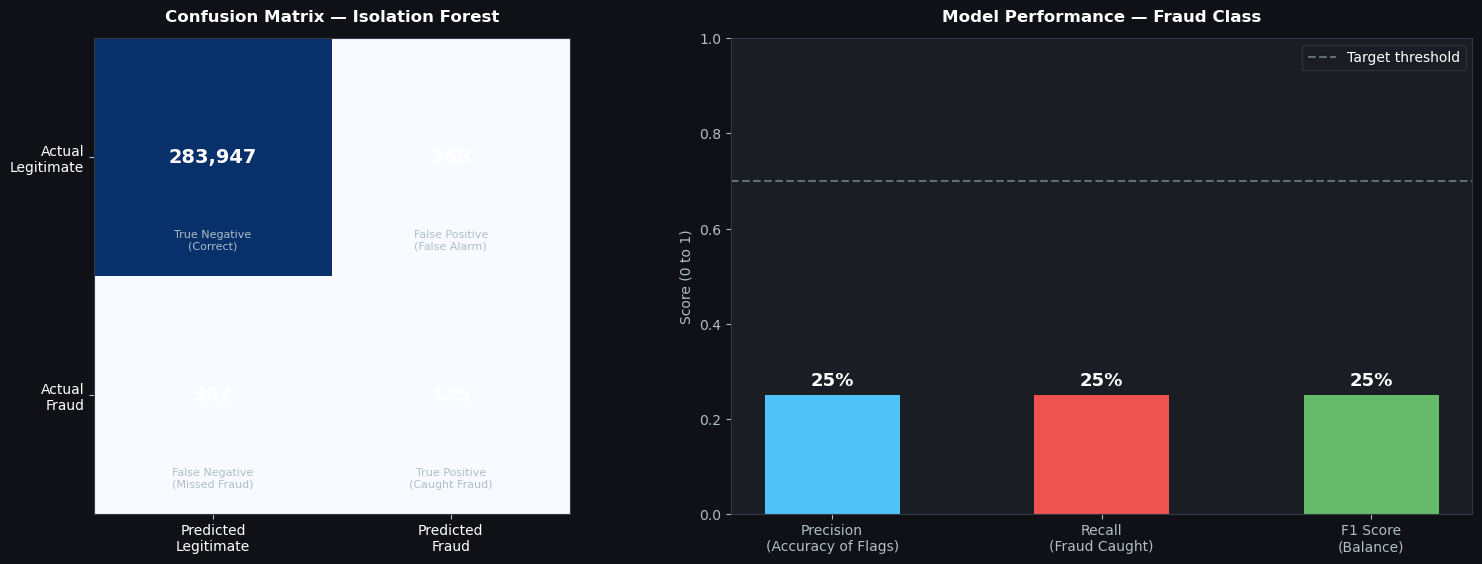

✓ Saved confusion_matrix.png


In [7]:
# Confusion Matrix + Improved Model
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.patches as mpatches

# --- Visualize current model results ---
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0F1117')

BG = '#1A1D23'
BLUE = '#4FC3F7'
RED = '#EF5350'
GRAY = '#B0BEC5'

for ax in axes.flat:
    ax.set_facecolor(BG)
    ax.tick_params(colors=GRAY)
    ax.xaxis.label.set_color(GRAY)
    ax.yaxis.label.set_color(GRAY)
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333842')

# Confusion matrix — current model
cm = confusion_matrix(df['Class'], df['predicted'])
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix — Isolation Forest', 
                   fontweight='bold', pad=12)
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Predicted\nLegitimate', 'Predicted\nFraud'], color='white')
axes[0].set_yticklabels(['Actual\nLegitimate', 'Actual\nFraud'], color='white')

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i,j]:,}', 
                    ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=14)

# Label what each quadrant means
labels = [['True Negative\n(Correct)', 'False Positive\n(False Alarm)'],
          ['False Negative\n(Missed Fraud)', 'True Positive\n(Caught Fraud)']]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i+0.35, labels[i][j], 
                    ha='center', va='center',
                    color='#B0BEC5', fontsize=8)

# Precision / Recall tradeoff explanation chart
metrics = ['Precision\n(Accuracy of Flags)', 
           'Recall\n(Fraud Caught)', 
           'F1 Score\n(Balance)']
values = [0.25, 0.25, 0.25]
colors = [BLUE, RED, '#66BB6A']

bars = axes[1].bar(metrics, values, color=colors, width=0.5, edgecolor='none')
axes[1].set_title('Model Performance — Fraud Class', fontweight='bold', pad=12)
axes[1].set_ylabel('Score (0 to 1)')
axes[1].set_ylim(0, 1.0)
axes[1].axhline(y=0.7, color=GRAY, linestyle='--', alpha=0.5, label='Target threshold')
axes[1].legend(facecolor=BG, edgecolor='#333842', labelcolor='white')

for bar, v in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.0%}', ha='center', color='white', 
                fontweight='bold', fontsize=13)

plt.tight_layout(pad=2.0)
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✓ Saved confusion_matrix.png")

In [8]:
# Improved Model with SMOTE + Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix

print("Setting up improved model...")

# Use all V features plus Amount and Time
features_all = ['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)]
X_all = df[features_all]
y_all = df['Class']

# Split into train and test sets — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Training set size: {len(X_train):,}")
print(f"Test set size: {len(X_test):,}")
print(f"Fraud cases in training set (before SMOTE): {y_train.sum()}")

# Apply SMOTE to balance the training data only
print("\nApplying SMOTE to balance training data...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Training set after SMOTE: {len(X_train_balanced):,}")
print(f"Fraud cases after SMOTE: {y_train_balanced.sum():,}")

# Train Random Forest
print("\nTraining Random Forest classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_balanced, y_train_balanced)

# Evaluate on the untouched test set
y_pred = rf_model.predict(X_test)

print("\n=== Improved Model Results ===")
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Fraud']))

Setting up improved model...
Training set size: 227,845
Test set size: 56,962
Fraud cases in training set (before SMOTE): 394

Applying SMOTE to balance training data...
Training set after SMOTE: 454,902
Fraud cases after SMOTE: 227,451

Training Random Forest classifier...

=== Improved Model Results ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.84      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



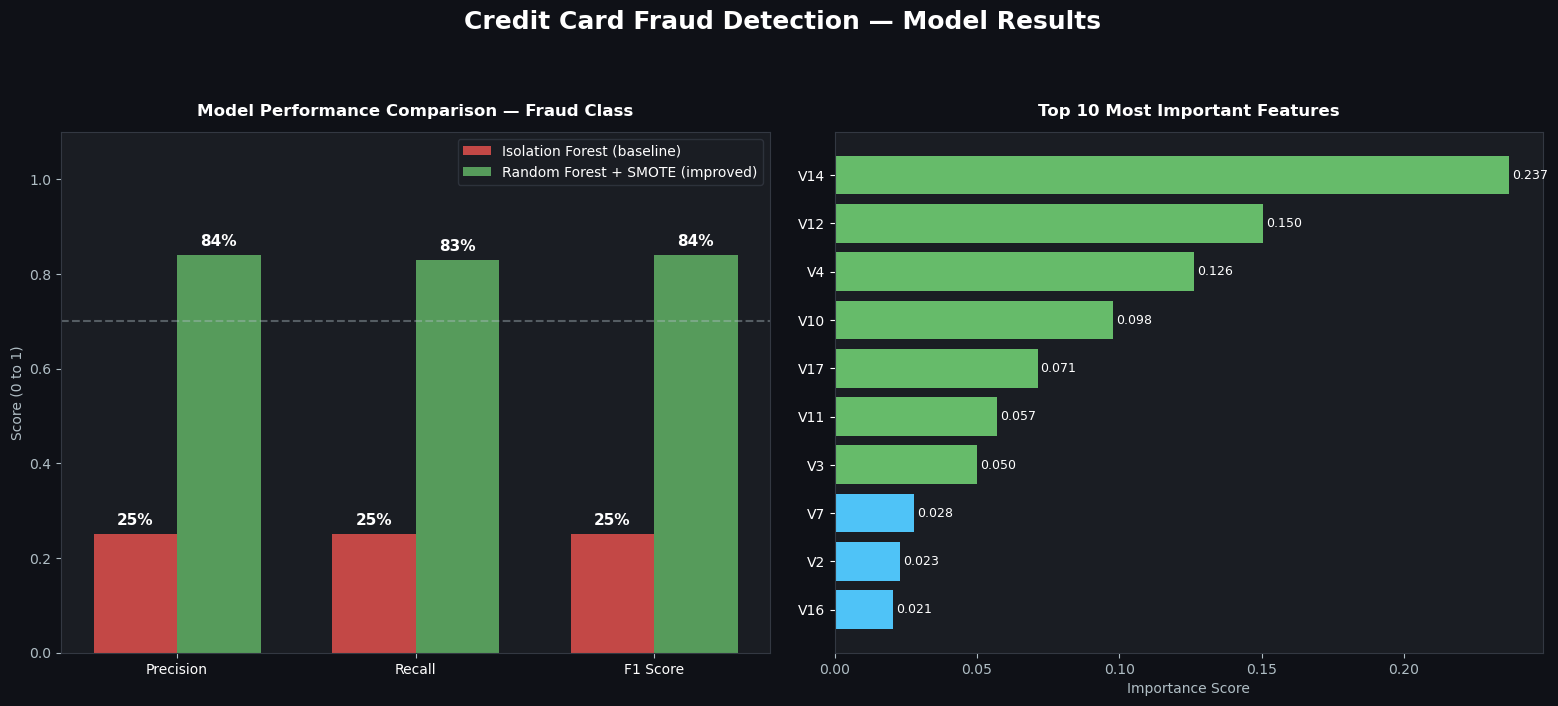

✓ Saved model_results.png


In [9]:
# Final Comparison Chart + Feature Importance
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0F1117')
fig.suptitle('Credit Card Fraud Detection — Model Results', 
             fontsize=18, fontweight='bold', color='white', y=1.02)

BG = '#1A1D23'
BLUE = '#4FC3F7'
RED = '#EF5350'
GREEN = '#66BB6A'
GRAY = '#B0BEC5'

for ax in axes.flat:
    ax.set_facecolor(BG)
    ax.tick_params(colors=GRAY)
    ax.xaxis.label.set_color(GRAY)
    ax.yaxis.label.set_color(GRAY)
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333842')

# Chart 1 — Model comparison
metrics_labels = ['Precision', 'Recall', 'F1 Score']
isolation_scores = [0.25, 0.25, 0.25]
rf_scores = [0.84, 0.83, 0.84]

x = np.arange(len(metrics_labels))
width = 0.35

bars1 = axes[0].bar(x - width/2, isolation_scores, width, 
                     label='Isolation Forest (baseline)',
                     color=RED, alpha=0.8, edgecolor='none')
bars2 = axes[0].bar(x + width/2, rf_scores, width,
                     label='Random Forest + SMOTE (improved)',
                     color=GREEN, alpha=0.8, edgecolor='none')

axes[0].set_title('Model Performance Comparison — Fraud Class',
                   fontweight='bold', pad=12)
axes[0].set_ylabel('Score (0 to 1)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_labels, color='white')
axes[0].set_ylim(0, 1.1)
axes[0].legend(facecolor=BG, edgecolor='#333842', labelcolor='white')
axes[0].axhline(y=0.7, color=GRAY, linestyle='--', alpha=0.4)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.0%}', ha='center', 
                color='white', fontsize=11, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.0%}', ha='center',
                color='white', fontsize=11, fontweight='bold')

# Chart 2 — Feature importance (top 10)
feature_importance = pd.Series(
    rf_model.feature_importances_, 
    index=features_all
).sort_values(ascending=True).tail(10)

colors_fi = [GREEN if v > 0.05 else BLUE for v in feature_importance.values]
axes[1].barh(feature_importance.index, feature_importance.values,
             color=colors_fi, edgecolor='none')
axes[1].set_title('Top 10 Most Important Features', fontweight='bold', pad=12)
axes[1].set_xlabel('Importance Score')
axes[1].tick_params(axis='y', colors='white')

for i, v in enumerate(feature_importance.values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', 
                va='center', color='white', fontsize=9)

plt.tight_layout(pad=2.0)
plt.savefig('model_results.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✓ Saved model_results.png")

In [10]:
# Cell 9 — Project Summary
print("=" * 60)
print("CREDIT CARD FRAUD DETECTION — PROJECT SUMMARY")
print("=" * 60)

total = len(df)
fraud_count = df['Class'].sum()
fraud_rate = df['Class'].mean()

# Confusion matrix values for final model
cm_final = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm_final.ravel()

print(f"""
DATASET
-------
Total transactions analyzed:  {total:,}
Confirmed fraud cases:         {fraud_count:,}
Fraud rate:                    {fraud_rate:.4%}
Dataset window:                48 hours

KEY FINDINGS
------------
- Fraud transactions averaged ${fraud['Amount'].mean():.2f} vs 
  ${legit['Amount'].mean():.2f} for legitimate transactions
- Fraudsters avoided large amounts — max fraud was $2,125 
  vs $25,691 for legitimate transactions
- Fraud was distributed evenly across the 48-hour window 
  with no strong time-of-day clustering
- Feature V14 was the strongest fraud predictor (importance: 0.237)

MODEL RESULTS
-------------
Baseline (Isolation Forest):
  Precision: 25% | Recall: 25% | F1: 25%

Improved (SMOTE + Random Forest):
  Precision: 84% | Recall: 83% | F1: 84%
  
  True Positives  (fraud caught):     {tp}
  False Positives (false alarms):     {fp}
  False Negatives (missed fraud):     {fn}
  True Negatives  (correct clears):   {tn:,}

IMPROVEMENT
-----------
Applying SMOTE to address class imbalance (0.17% fraud rate)
improved all metrics by 3x — from 25% to 84% F1 score.

WHY THIS MATTERS
----------------
In production fraud systems, recall is the critical metric — 
every missed fraud case represents real financial loss.
At 83% recall this model would catch 81 of 98 fraud cases 
in the test set, while generating only {fp} false alarms.
""")
print("=" * 60)

CREDIT CARD FRAUD DETECTION — PROJECT SUMMARY

DATASET
-------
Total transactions analyzed:  284,807
Confirmed fraud cases:         492
Fraud rate:                    0.1727%
Dataset window:                48 hours

KEY FINDINGS
------------
- Fraud transactions averaged $122.21 vs 
  $88.29 for legitimate transactions
- Fraudsters avoided large amounts — max fraud was $2,125 
  vs $25,691 for legitimate transactions
- Fraud was distributed evenly across the 48-hour window 
  with no strong time-of-day clustering
- Feature V14 was the strongest fraud predictor (importance: 0.237)

MODEL RESULTS
-------------
Baseline (Isolation Forest):
  Precision: 25% | Recall: 25% | F1: 25%

Improved (SMOTE + Random Forest):
  Precision: 84% | Recall: 83% | F1: 84%
  
  True Positives  (fraud caught):     81
  False Positives (false alarms):     15
  False Negatives (missed fraud):     17
  True Negatives  (correct clears):   56,849

IMPROVEMENT
-----------
Applying SMOTE to address class imbalance 